In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

df = pd.read_csv(r'C:\Users\ALG\OneDrive\Documents\olist-ecommerce-analysis\data\cleaned\olist_master.csv',
                 parse_dates=['order_purchase_timestamp'])

print(f"Data loaded: {df.shape}")
print(f"Unique customers: {df['customer_unique_id'].nunique()}")

Data loaded: (96477, 26)
Unique customers: 93357


In [2]:
# Snapshot date = 1 day after last order
snapshot = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp',
                 lambda x: (snapshot - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('payment_value', 'sum')
).reset_index()

print(rfm.describe().round(2))
print(f"\nTotal customers: {len(rfm)}")
print(f"Customers who bought MORE than once: {(rfm['frequency'] > 1).sum()}")
print(f"One-time buyers: {(rfm['frequency'] == 1).sum()}")
print(f"Repeat rate: {(rfm['frequency'] > 1).mean()*100:.1f}%")

        recency  frequency  monetary
count  93357.00   93357.00  93357.00
mean     237.94       1.03    165.20
std      152.58       0.21    226.31
min        1.00       1.00      9.59
25%      114.00       1.00     63.06
50%      219.00       1.00    107.78
75%      346.00       1.00    182.56
max      695.00      15.00  13664.08

Total customers: 93357
Customers who bought MORE than once: 2801
One-time buyers: 90556
Repeat rate: 3.0%


In [3]:
# Score each customer 1-4
rfm['R_score'] = pd.qcut(rfm['recency'],   q=4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['monetary'],  q=4, labels=[1,2,3,4])

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

def segment(row):
    r, f = row['R_score'], row['F_score']
    if r >= 3 and f >= 3:   return 'Champion'
    elif r >= 3 and f >= 2: return 'Loyal'
    elif r >= 2 and f == 1: return 'Potential'
    elif r <= 2 and f >= 3: return 'At Risk'
    else:                   return 'Lost'

rfm['segment'] = rfm.apply(segment, axis=1)

summary = rfm.groupby('segment').agg(
    customers  = ('customer_unique_id', 'count'),
    avg_revenue= ('monetary', 'mean'),
    total_rev  = ('monetary', 'sum')
).round(2).sort_values('total_rev', ascending=False)

print(summary)
rfm.to_csv(r'C:\Users\ALG\OneDrive\Documents\olist-ecommerce-analysis\data\cleaned\rfm_segments.csv', index=False)
print("\n✓ Saved rfm_segments.csv")

           customers  avg_revenue   total_rev
segment                                      
Champion       23491       172.42  4050397.41
At Risk        23187       166.41  3858648.41
Potential      17440       161.38  2814442.12
Lost           17560       160.26  2814128.65
Loyal          11679       161.39  1884845.18

✓ Saved rfm_segments.csv


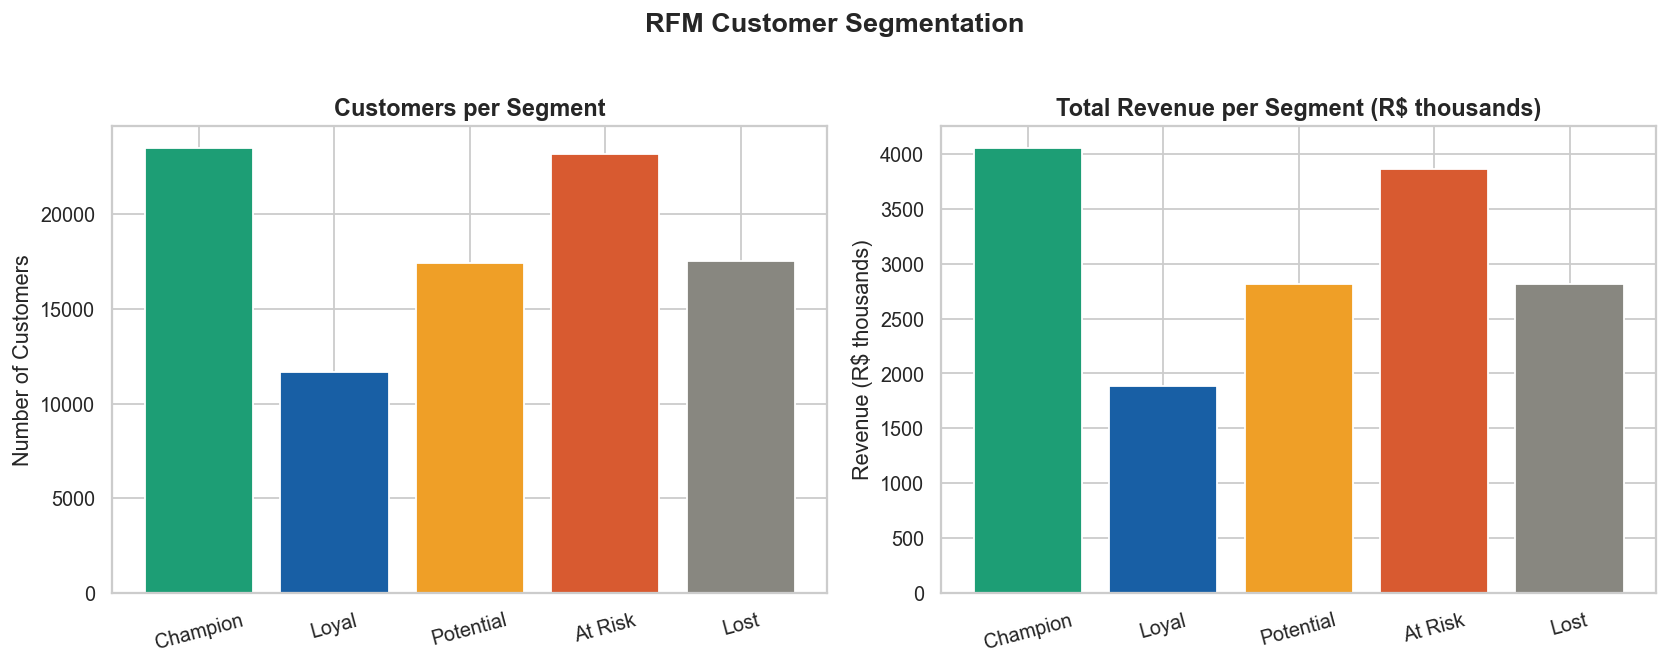

✓ Chart saved!


In [4]:
seg_order = ['Champion','Loyal','Potential','At Risk','Lost']
colors = ['#1D9E75','#185FA5','#EF9F27','#D85A30','#888780']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Customer count per segment
counts = rfm['segment'].value_counts().reindex(seg_order)
ax1.bar(seg_order, counts.values, color=colors, edgecolor='white')
ax1.set_title('Customers per Segment', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Customers')
ax1.tick_params(axis='x', rotation=15)

# Revenue per segment
revs = rfm.groupby('segment')['monetary'].sum().reindex(seg_order)
ax2.bar(seg_order, revs.values/1000, color=colors, edgecolor='white')
ax2.set_title('Total Revenue per Segment (R$ thousands)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Revenue (R$ thousands)')
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('RFM Customer Segmentation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\ALG\OneDrive\Documents\olist-ecommerce-analysis\assets\rfm_segments.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved!")

## RFM Segmentation Findings

### Key Insight: 97% of Customers Never Returned
Out of 93,357 unique customers, only 2,801 (3%) made more than one purchase.
This represents a massive customer retention problem for Olist.

### Segment Breakdown:
- **Champions (23,491 customers):** Most recent, most frequent buyers. 
  Generate R$4M+ in revenue — the highest of all segments.
  These are Olist's most valuable customers to retain.

- **At Risk (23,187 customers):** Previously good customers who haven't 
  bought recently. Revenue at risk: R$3.8M. 
  Target with re-engagement campaigns immediately.

- **Potential (17,440 customers):** Bought recently but infrequently.
  Opportunity to convert into Loyal/Champion with targeted offers.

- **Lost (17,560 customers):** Haven't bought in a long time.
  Low chance of recovery — low priority for marketing spend.

- **Loyal (11,679 customers):** Regular buyers but lower monetary value.
  Upsell opportunity with premium product recommendations.

### Business Recommendation:
Focus retention budget on At Risk segment — R$3.8M revenue is at stake.

A 10% recovery of At Risk customers = R$380K additional revenue.